# Module 3 Fire, Soil, and Water Impacts
**Region:** Cache la Poudre watershed/2020 Cameron Peak Fire burn scar

This is the chain that makes the wildfire and soil-watershed stories one
story: burn severity (from `wildfire-landscape-intelligence`) changes soil
properties, which changes runoff, which changes watershed vulnerability.
Every layer here is built with the same toolkit functions
`wildfire-landscape-intelligence` uses, this notebook just carries the
chain one step further.

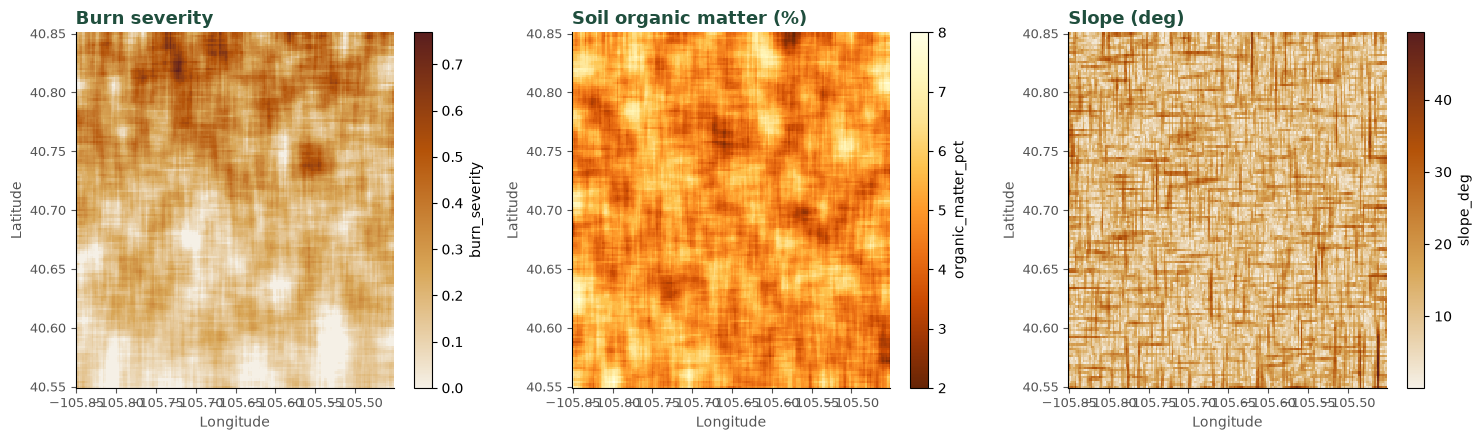

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

burn = data_access.get_burn_severity(BBOX, fire_year=REGION.fire_year)
terrain = data_access.get_terrain(BBOX)
soil = data_access.get_soil_properties(BBOX)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
viz.plot_raster(burn, title="Burn severity", ax=axes[0], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(soil["organic_matter_pct"], title="Soil organic matter (%)", ax=axes[1], cmap="YlOrBr_r")
viz.plot_raster(terrain["slope_deg"], title="Slope (deg)", ax=axes[2], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/03_inputs.png", dpi=150)
plt.show()

## Fire's effect on soil vulnerability

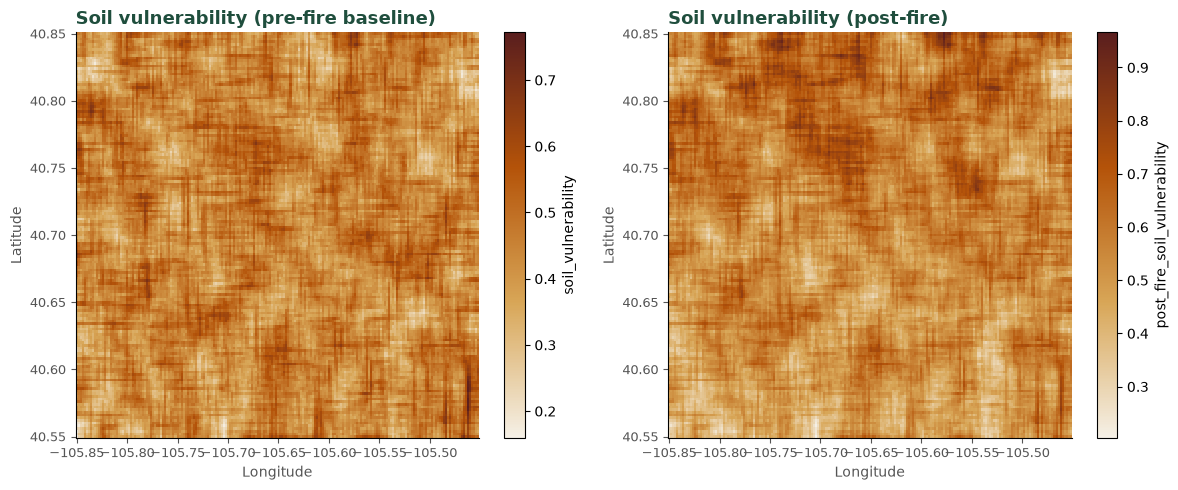

Mean soil vulnerability, pre-fire:  0.448
Mean soil vulnerability, post-fire: 0.562


In [ ]:
soil_vuln = indicators.soil_vulnerability(
    soil["organic_matter_pct"], soil["sand_fraction_pct"], terrain["slope_deg"]
)

# Fire compounds soil vulnerability: burned organic matter, hydrophobic soil
# layers, and exposed ground push vulnerability up in proportion to burn
# severity. This simplified compounding factor is illustrative -- a live
# deployment would use published post-fire soil-hydrophobicity relationships.
post_fire_soil_vuln = (soil_vuln + 0.5 * burn).clip(0, 1)
post_fire_soil_vuln.name = "post_fire_soil_vulnerability"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(soil_vuln, title="Soil vulnerability (pre-fire baseline)", ax=axes[0], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(post_fire_soil_vuln, title="Soil vulnerability (post-fire)", ax=axes[1], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/03_soil_vulnerability_before_after.png", dpi=150)
plt.show()

print(f"Mean soil vulnerability, pre-fire:  {float(soil_vuln.mean()):.3f}")
print(f"Mean soil vulnerability, post-fire: {float(post_fire_soil_vuln.mean()):.3f}")

## Soil vulnerability's effect on runoff and erosion

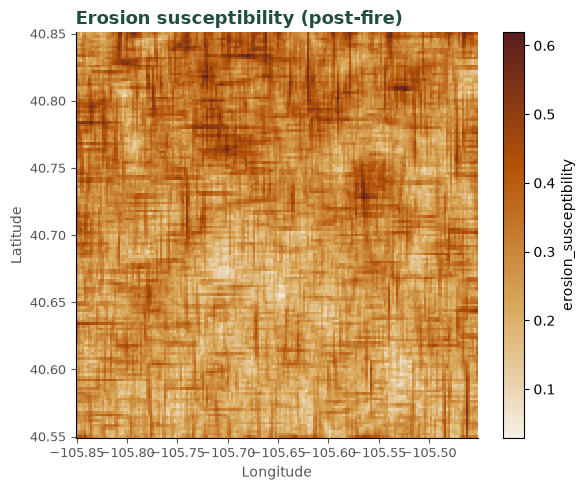

Correlation, post-fire soil vulnerability vs. erosion susceptibility: 0.74


In [ ]:
erosion = indicators.erosion_susceptibility(terrain["slope_deg"], burn, soil["runoff_potential"])

fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(erosion, title="Erosion susceptibility (post-fire)", ax=ax, cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/03_erosion_susceptibility.png", dpi=150)
plt.show()

# Relationship check: does higher post-fire soil vulnerability track with
# higher erosion susceptibility, as the causal chain implies?
corr = np.corrcoef(post_fire_soil_vuln.values.flatten(), erosion.values.flatten())[0, 1]
print(f"Correlation, post-fire soil vulnerability vs. erosion susceptibility: {corr:.2f}")

## Watershed resilience is the composite this feeds into `climate-resilience-indicators`

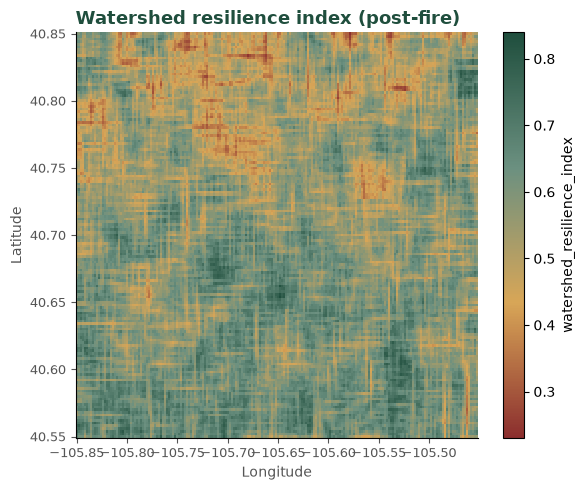

Mean watershed resilience: 0.573  (1 = most resilient, 0 = least)
Area-fraction low resilience (<0.4): 3.0%


In [ ]:
resilience = indicators.watershed_resilience_index(erosion, post_fire_soil_vuln)

fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(resilience, title="Watershed resilience index (post-fire)", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/03_watershed_resilience.png", dpi=150)
plt.show()

print(f"Mean watershed resilience: {float(resilience.mean()):.3f}  (1 = most resilient, 0 = least)")
print(f"Area-fraction low resilience (<0.4): {float((resilience < 0.4).mean()):.1%}")

## Summary

Fire creates soil vulnerability then erosion susceptibility that impacts watershed resilience,
computed as one chain. 
